# Title: Answering Questions from Survey Results
# Name: Maxwell Yung
# Date: 3/2/25

First, we need to read in the cleaned CSV from part 2

In [1]:
import pandas as pd
datafile = "cleaned.csv"
df = pd.read_csv(datafile)

In [4]:
df.columns

Index(['Unnamed: 0', 'hs_class', 'ap_class', 'dual_enrollment',
       'interest_level', 'current_course', 'enrichment', 'curiosity',
       'degree_program', 'age', 'web', 'cybersecurity', 'apps', 'analytics',
       'ml_ai', 'programming', 'gamedev', 'hardware'],
      dtype='object')

### Now, we answer the questions with the cleaned dataset

Using matplotlib will be useful for graphing out answers

In [2]:
import matplotlib.pyplot as plt

Question 2: Which class is the most likely to be taken for someone's passion (personal enrichment or curiosity)? (current_course, enrichment, curiosity)

Answer: CMP 101 is the most engaging class, leading to the highest rating of enrichment and curiosity

In [35]:
df['enrichment'] = df['enrichment'].map({'Yes': 1, 'No': 0}) #shout out to copilot to convert yes/no values into binary
df['curiosity']  = df['curiosity'].map({'Yes': 1, 'No': 0})

df.groupby('current_course')[['enrichment','curiosity']].mean()

,enrichment,curiosity
current_course,,
CMP 101 Computer Information Literacy,0.590909,0.727273
CMP 126 Computer Technology and Applications,0.466667,0.400000
CMP 135 Computer Concepts with Applications,0.525000,0.475000


Question 3: Which programs have the most students who are enthusiastic about computer science? (interest_level, degree_program)

Answer: Biology has the highest average interest, followed by early childhood education. Nursing NOT from CCM has the least interest

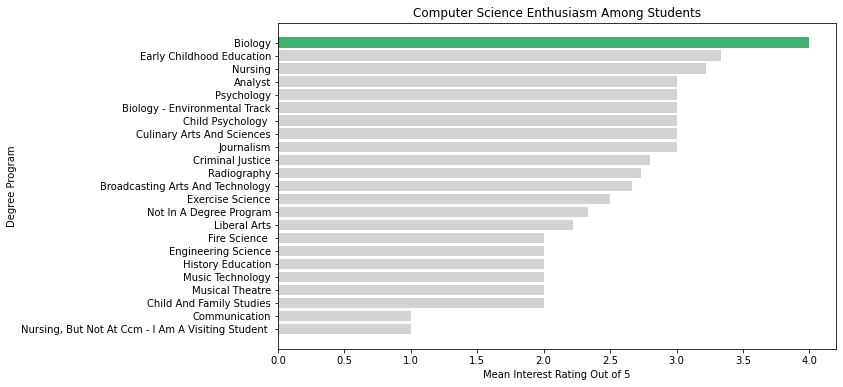

In [13]:
df['degree_program'] = df['degree_program'].str.title()
avg = df.groupby('degree_program').interest_level.mean().sort_values()
x = avg.index
y = avg.values

colors = ['mediumseagreen' if val > 3.9 else 'lightgrey' for val in avg.values]
plt.figure(figsize=(10, 6))
plt.barh(x, y, color=colors)
plt.title("Computer Science Enthusiasm Among Students")
plt.xlabel("Mean Interest Rating Out of 5")
plt.ylabel("Degree Program")
plt.show()

In [16]:
df.groupby('degree_program').interest_level.mean().sort_values(ascending=False) #easier way to see values

degree_program
Biology                                               4.000000
Early Childhood Education                             3.333333
Nursing                                               3.222222
analyst                                               3.000000
Psychology                                            3.000000
Journalism                                            3.000000
Biology - Environmental Track                         3.000000
child psychology                                      3.000000
Culinary Arts and Sciences                            3.000000
Criminal Justice                                      2.800000
Radiography                                           2.730769
Broadcasting Arts and Technology                      2.666667
Exercise Science                                      2.500000
Not in a degree program                               2.333333
Liberal Arts                                          2.222222
Engineering Science                     

Question 4: Which specific computer science classes have the most interest? (web, cybersecurity, apps, analytics, ml_ai, programming, gamedev, hardware, interest_level)

Answer: It looks like cybersecurity sparks the most interest, with machine learning and gamedev being close seconds.

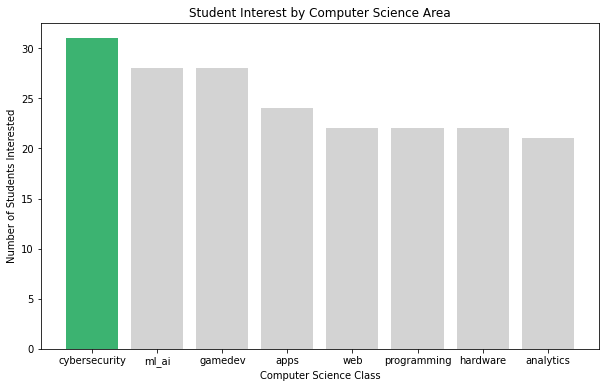

In [35]:
fields = [
    'web',
    'cybersecurity',
    'apps',
    'analytics',
    'ml_ai',
    'programming',
    'gamedev',
    'hardware'
]

yuh = {}
for col in fields:
    yuh[col] = (df[col] == 'Yes').sum()

yuhs = pd.Series(yuh).sort_values(ascending=False)
yuhs

colors = ['mediumseagreen' if val > 29 else 'lightgrey' for val in yuhs.values]
plt.figure(figsize=(10, 6))
plt.bar(yuhs.index, yuhs.values, color=colors)
plt.title("Student Interest by Computer Science Area")
plt.xlabel("Computer Science Class")
plt.ylabel("Number of Students Interested")
plt.show()

Question 5: What age group is the least enthusiastic about computer science? (age, interest_level)

Answer: The bar graph indicates that the age group with the least interest is 19-20

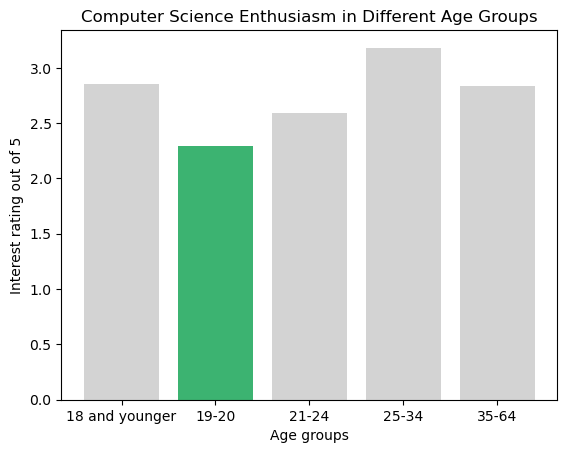

In [9]:
avg = df.groupby('age').interest_level.mean() #thank you copilot for helping assign x/y
x = avg.index
y = avg.values
colors = ['mediumseagreen' if val < 2.5 else 'lightgrey' for val in avg.values]
plt.bar(x, y, color=colors)
plt.title("Computer Science Enthusiasm in Different Age Groups")
plt.xlabel("Age groups")
plt.ylabel("Interest rating out of 5")
plt.show()